In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import inception_v3
from tqdm import tqdm
from PIL import Image
from scipy.linalg import sqrtm
import torch.nn.functional as F


In [2]:
class YelpDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, sample_size=30000):
        self.data = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        # Sample a subset of data
        self.data = self.data.sample(n=sample_size, random_state=42).reset_index(drop=True)

        # Remove corrupted images
        self.valid_images = []
        for i, row in tqdm(self.data.iterrows(), total=len(self.data), desc="Filtering Valid Images"):
            img_path = os.path.join(self.root_dir, f"{row['photo_id']}.jpg")  # Assuming image format is .jpg
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Check if the image is valid
                self.valid_images.append(row)
            except Exception as e:
                continue  # Skip corrupted images
        
        self.data = pd.DataFrame(self.valid_images)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, f"{self.data.iloc[idx]['photo_id']}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

# Define transformations
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize images
    transforms.ToTensor(),        # Convert to tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize
])

# Load dataset
dataset = YelpDataset(
    csv_file=r"C:\Users\anjit\Computer Vision\photos.csv",
    root_dir=r"C:\Users\anjit\Computer Vision\images",
    transform=transform
)

dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

print(f"Dataset loaded with {len(dataset)} valid images.")


Filtering Valid Images: 100%|████████████████████████████████████████████████████| 30000/30000 [07:44<00:00, 64.57it/s]


Dataset loaded with 29987 valid images.


In [3]:
# Generator Model
class Generator(nn.Module):
    def __init__(self, nz, ngf, nc):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# Critic Model
class Critic(nn.Module):
    def __init__(self, nc, ndf):
        super(Critic, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, input):
        return self.main(input).view(-1)


In [4]:
print(f"Dataset size: {len(dataset)}")
print(f"First image shape: {dataset[0].shape}")


Dataset size: 29987
First image shape: torch.Size([3, 64, 64])


In [5]:
from tqdm import tqdm  # Progress bar

nz = 100  # Latent vector size
ngf = 64  # Generator feature maps
ndf = 64  # Critic feature maps
nc = 3    # Image channels

device = "cuda" if torch.cuda.is_available() else "cpu"

netG = Generator(nz, ngf, nc).to(device)
netD = Critic(nc, ndf).to(device)

optimizerG = optim.Adam(netG.parameters(), lr=0.0001, betas=(0.5, 0.9))
optimizerD = optim.Adam(netD.parameters(), lr=0.0001, betas=(0.5, 0.9))

num_epochs = 30

for epoch in range(num_epochs):
    loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
    for i, real_images in enumerate(loop):
        real_images = real_images.to(device)

        # Train Critic
        optimizerD.zero_grad()
        noise = torch.randn(real_images.size(0), nz, 1, 1, device=device)
        fake_images = netG(noise)
        lossD = netD(fake_images).mean() - netD(real_images).mean()
        lossD.backward()
        optimizerD.step()

        # Train Generator
        optimizerG.zero_grad()
        noise = torch.randn(real_images.size(0), nz, 1, 1, device=device)
        fake_images = netG(noise)
        lossG = -netD(fake_images).mean()
        lossG.backward()
        optimizerG.step()

        # Update progress bar with loss values
        loop.set_postfix(lossD=lossD.item(), lossG=lossG.item())

    print(f"Epoch {epoch+1}/{num_epochs} | Loss D: {lossD.item():.4f} | Loss G: {lossG.item():.4f}")


Epoch 1/30: 100%|█████████████████████████████████████████| 235/235 [34:53<00:00,  8.91s/it, lossD=-2.45, lossG=-0.579]


Epoch 1/30 | Loss D: -2.4506 | Loss G: -0.5795


Epoch 2/30: 100%|███████████████████████████████████████████| 235/235 [36:36<00:00,  9.35s/it, lossD=-4.54, lossG=9.26]


Epoch 2/30 | Loss D: -4.5428 | Loss G: 9.2581


Epoch 3/30: 100%|███████████████████████████████████████████| 235/235 [35:56<00:00,  9.18s/it, lossD=-2.94, lossG=9.27]


...

Epoch 28/30 | Loss D: -42.7724 | Loss G: 126.1926


Epoch 29/30: 100%|█████████████████████████████████████████| 235/235 [1:01:09<00:00, 15.61s/it, lossD=-23.6, lossG=107]


Epoch 29/30 | Loss D: -23.5569 | Loss G: 106.8664


Epoch 30/30: 100%|█████████████████████████████████████████| 235/235 [1:00:46<00:00, 15.52s/it, lossD=-31.7, lossG=106]

Epoch 30/30 | Loss D: -31.7155 | Loss G: 106.3952


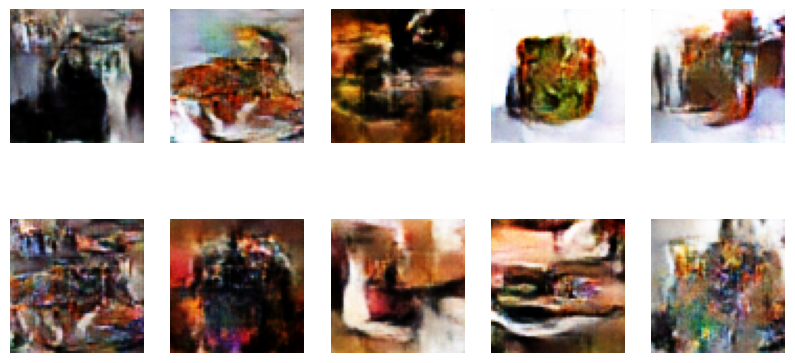

In [6]:
noise = torch.randn(10, nz, 1, 1, device=device)  # Generate 10 images
generated_images = netG(noise).detach().cpu()

# Display Images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = generated_images[i].permute(1, 2, 0) * 0.5 + 0.5
    ax.imshow(img)
    ax.axis("off")
plt.show()


In [9]:
import torch.nn.functional as F

real_images = F.adaptive_avg_pool2d(real_images, (299, 299))
fake_images = F.adaptive_avg_pool2d(fake_images, (299, 299))


In [13]:
import torch
import torch.nn.functional as F
import numpy as np
from torchvision.models import inception_v3
from scipy.linalg import sqrtm

def get_inception_features(images, model, device):
    """Extracts features from the InceptionV3 model"""
    images = images.to(device)
    with torch.no_grad():
        features = model(images).cpu().numpy()  # Move features to CPU
    return features

def compute_fid(real_images, fake_images, device='cpu'):
    """Computes Frechet Inception Distance (FID)"""
    model = inception_v3(pretrained=True, transform_input=False).eval().to(device)

    # Resize images to 299x299
    real_images = F.adaptive_avg_pool2d(real_images, (299, 299))
    fake_images = F.adaptive_avg_pool2d(fake_images, (299, 299))

    # Extract features from the Inception model
    real_features = get_inception_features(real_images, model, device)
    fake_features = get_inception_features(fake_images, model, device)

    # Compute mean and covariance
    mu_real, sigma_real = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu_fake, sigma_fake = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)

    # Compute FID score
    diff = mu_real - mu_fake
    cov_sqrt, _ = sqrtm(sigma_real @ sigma_fake, disp=False)

    # Ensure the sqrtm result is a real matrix
    if np.iscomplexobj(cov_sqrt):
        cov_sqrt = cov_sqrt.real

    fid = np.sum(diff**2) + np.trace(sigma_real + sigma_fake - 2 * cov_sqrt)
    return fid

def compute_inception_score(images, model, device, splits=10):
    """Computes Inception Score (IS)"""
    images = F.adaptive_avg_pool2d(images, (299, 299)).to(device)
    
    with torch.no_grad():
        preds = torch.nn.functional.softmax(model(images), dim=1).cpu().numpy()

    # Split into groups for stability
    split_scores = []
    for i in range(splits):
        part = preds[i * (len(preds) // splits): (i + 1) * (len(preds) // splits)]
        p_y = np.mean(part, axis=0)
        kl_div = part * (np.log(part) - np.log(p_y))
        split_scores.append(np.exp(np.mean(np.sum(kl_div, axis=1))))

    return np.mean(split_scores), np.std(split_scores)

# Run on CPU
device = 'cpu'
real_images = torch.randn(10, 3, 64, 64)  # Simulated real images
generated_images = torch.randn(10, 3, 64, 64)  # Simulated generated images

# Load Inception model
model = inception_v3(pretrained=True, transform_input=False).eval().to(device)

# Compute FID
fid_score = compute_fid(real_images, generated_images, device)
print(f"FID Score: {fid_score}")

# Compute IS
is_mean, is_std = compute_inception_score(generated_images, model, device)
print(f"Inception Score: {is_mean} ± {is_std}")


FID Score: 98.46192512342097
Inception Score: 1.0 ± 0.0
